In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder , StandardScaler 
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import Ridge

from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score

In [3]:
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

In [4]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [5]:
df.shape

(2640, 12)

In [6]:
# DATA PREPROCESSING : handling the missing values , duplicate values

In [7]:
# MISSING VALUES 
print(df.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [8]:
# REMOVING DUPLICATES
df.drop_duplicates(inplace = True)

In [9]:
# EDA(EXPLORATORY DATA ANALYSIS)

In [10]:
print(df.describe())

              Year        Month  Estimated_Deliveries  Production_Units  \
count  2640.000000  2640.000000           2640.000000       2640.000000   
mean   2020.000000     6.500000           9922.199621      10655.847348   
std       3.162877     3.452707           3935.950093       4260.600858   
min    2015.000000     1.000000             48.000000         50.000000   
25%    2017.000000     3.750000           7292.000000       7828.250000   
50%    2020.000000     6.500000           9857.000000      10546.500000   
75%    2023.000000     9.250000          12510.250000      13469.000000   
max    2025.000000    12.000000          25704.000000      28939.000000   

       Avg_Price_USD  Battery_Capacity_kWh     Range_km  CO2_Saved_tons  \
count    2640.000000           2640.000000  2640.000000     2640.000000   
mean    84907.340330             87.059470   500.257576      744.076989   
std     20123.258036             20.836265   120.868549      353.221224   
min     50003.700000    

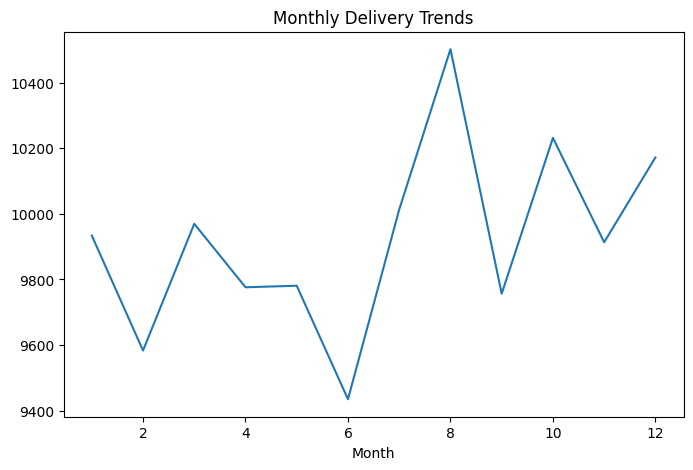

In [11]:
# TRENDS
month = df.groupby("Month")["Estimated_Deliveries"].mean()

month.plot(figsize = (8 , 5)) 

plt.title("Monthly Delivery Trends")
plt.show()

In [12]:
# FEATURE ENGINEERING 

In [13]:
# Creating a new feature
df["Efficency"] = df["Estimated_Deliveries"] / df["Production_Units"]

In [14]:
print(df["Efficency"])

0       0.984600
1       0.911864
2       0.915334
3       0.896594
4       0.914087
          ...   
2635    0.941045
2636    0.994187
2637    0.895680
2638    0.934572
2639    0.900990
Name: Efficency, Length: 2640, dtype: float64


In [15]:
X = df.drop("Estimated_Deliveries" , axis = 1) 
y = df["Estimated_Deliveries"]

In [16]:
print(X)

      Year  Month         Region       Model  Production_Units  Avg_Price_USD  \
0     2023      5         Europe     Model S             17922       92874.27   
1     2015      2           Asia     Model X              4164       62205.65   
2     2019      1  North America     Model X              9189      117887.32   
3     2021      2  North America     Model 3              7311       89294.91   
4     2016     12    Middle East     Model Y             13537      114846.78   
...    ...    ...            ...         ...               ...            ...   
2635  2021     10    Middle East     Model Y             14333      113771.10   
2636  2019      7    Middle East     Model S             18407       81889.67   
2637  2019      9           Asia     Model S             14839       97139.38   
2638  2020      5           Asia  Cybertruck              3714       69990.57   
2639  2018      8  North America     Model S              2929       51676.24   

      Battery_Capacity_kWh 

In [17]:
print(y)

0       17646
1        3797
2        8411
3        6555
4       12374
        ...  
2635    13488
2636    18300
2637    13291
2638     3471
2639     2639
Name: Estimated_Deliveries, Length: 2640, dtype: int64


In [18]:
categorical_col = ["Region" , "Model" , "Source_Type"]

numerical_col = [
    col for col in X.columns
    if col not in categorical_col
]

In [19]:
print(categorical_col)

['Region', 'Model', 'Source_Type']


In [20]:
print(numerical_col)

['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Efficency']


In [21]:
# PIPELINE CREATION

In [22]:
# OneHotEncoding and Scaling 

preprocess = ColumnTransformer(
    transformers = [
        ("num" , StandardScaler() , numerical_col) , 
        ("cat" , OneHotEncoder(handle_unknown="ignore") , categorical_col)
    ]
)

In [23]:
#  Train-Test Split for training the model 

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.6 , random_state = 42)

In [24]:
pipeline = Pipeline(
    steps = [
        ("preprocess" , preprocess) , 
        ("model" , Ridge()) 
    ]
)

In [25]:
# HYPER-PARAMETER TUNING 

In [26]:
param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

In [27]:
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="r2"
)

grid_search.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting

In [28]:
best_model = grid_search.best_estimator_

print("best Alpha is : " , grid_search.best_params_)

best Alpha is :  {'model__alpha': 0.1}


In [29]:
# PREDICITON
y_pred = best_model.predict(X_test)

In [30]:
y_pred

array([ 6875.74340779,  9302.85214819,  9067.57531669, ...,
        1617.00572905,  3581.27273488, 13478.32659562], shape=(1584,))

In [31]:
# EVALUATION METRICS 
 
MAE = mean_absolute_error(y_test , y_pred) 
MSE = mean_squared_error(y_test , y_pred)
RMSE = np.sqrt(mean_squared_error(y_test , y_pred))
R2_score = r2_score(y_test , y_pred) 

print("MAE (mean absolute error) : " , MAE) 
print("MSE (mean squared error) : " , MSE) 
print("RMSE (root mean squared error) : " , RMSE)
print("r2_score : " , R2_score)

MAE (mean absolute error) :  110.39788263218593
MSE (mean squared error) :  25007.947919280916
RMSE (root mean squared error) :  158.1390145387308
r2_score :  0.9984175053198481


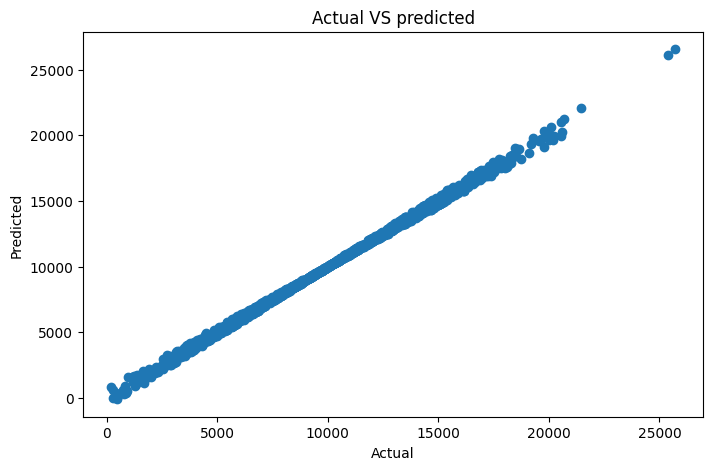

In [32]:
plt.figure(figsize = (8,5)) 

plt.scatter(y_test , y_pred) 
plt.xlabel("Actual")
plt.ylabel("Predicted") 

plt.title("Actual VS predicted")

plt.show()

In [33]:
# TIME SERIES FORECASTING 

In [34]:
# Creating Time Series 

ts = (df.groupby(["Year" , "Month"])["Estimated_Deliveries"].sum().reset_index())

ts["Date"] = pd.to_datetime(ts["Year"].astype(str) + "-" + ts["Month"].astype(str) + "-01")

ts = ts.sort_values("Date")

print(ts.head())

   Year  Month  Estimated_Deliveries       Date
0  2015      1                183180 2015-01-01
1  2015      2                165053 2015-02-01
2  2015      3                184567 2015-03-01
3  2015      4                225623 2015-04-01
4  2015      5                184264 2015-05-01


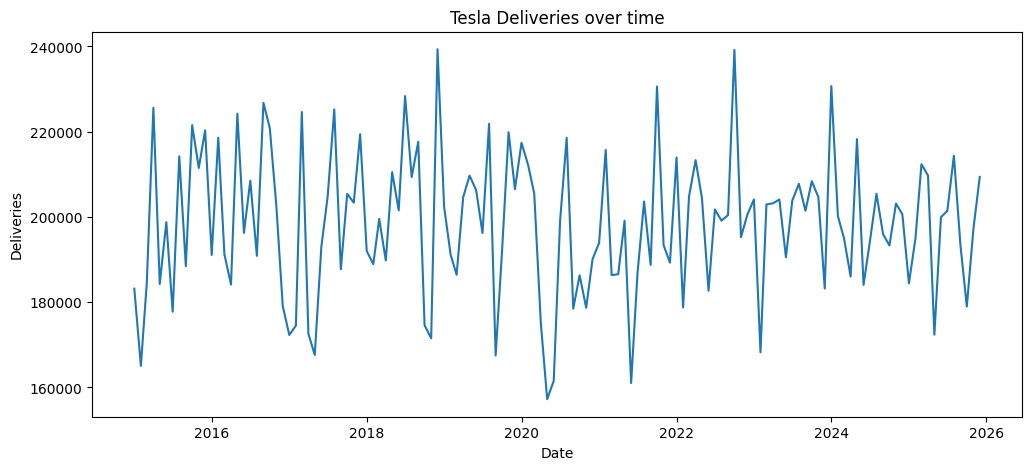

In [35]:
# Trends

plt.figure(figsize = (12 , 5)) 

plt.plot(ts["Date"] , ts["Estimated_Deliveries"])

plt.title("Tesla Deliveries over time")
plt.xlabel("Date")
plt.ylabel("Deliveries")

plt.show()

In [36]:
# Lag Feature Creation

ts["lag_1"] = ts["Estimated_Deliveries"].shift(1) 
ts["lag_2"] = ts["Estimated_Deliveries"].shift(2) 
ts["lag_3"] = ts["Estimated_Deliveries"].shift(3) 

In [37]:
# Rolling Statitics

ts["rolling_mean"] = (ts["Estimated_Deliveries"].rolling(3).mean())

In [38]:
# Remove null rows

ts.dropna(inplace = True)

In [39]:
from statsmodels.tsa.stattools import adfuller

res = adfuller(ts["Estimated_Deliveries"])

print("ADF statitics : " , res[0])
print("p-value : " , res[1])

if res[1] < 0.05 : 
    print("series is stationary")
else :
    print("series is not stationary")

ADF statitics :  -11.33759545962439
p-value :  1.074120620924651e-20
series is stationary


In [40]:
X = ts[["lag_1" , "lag_2" , "lag_3" , "rolling_mean"]]
y = ts["Estimated_Deliveries"]

In [41]:
# Chronological Train-Test Split

split = int(len(ts) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [42]:
# Training ForeCasting Model

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-1.,-1.,-0., 3.]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['lag_1','lag_2','lag_3','rolling_mean']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.821e-11
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [43]:
# Predictions 

y_pred = model.predict(X_test)

In [44]:
y_pred

array([204620., 183198., 230697., 200193., 194961., 186011., 218256.,
       184061., 194250., 205440., 195968., 193298., 203136., 200628.,
       184411., 195061., 212368., 209709., 172377., 199951., 201390.,
       214357., 193337., 178964., 197146., 209391.])

In [45]:
# Evaluation 

MAE = mean_absolute_error(y_test , y_pred)
MSE = mean_squared_error(y_test , y_pred)
RMSE = np.sqrt(mean_squared_error(y_test , y_pred))
r2_score = r2_score(y_test , y_pred)

print("MAE : " , MAE)
print("MSE : " , MSE)
print("RMSE : " , RMSE)
print("r2_score : " , r2_score)

MAE :  6.828206376387523e-11
MSE :  5.961808821059114e-21
RMSE :  7.721275037880151e-11
r2_score :  1.0


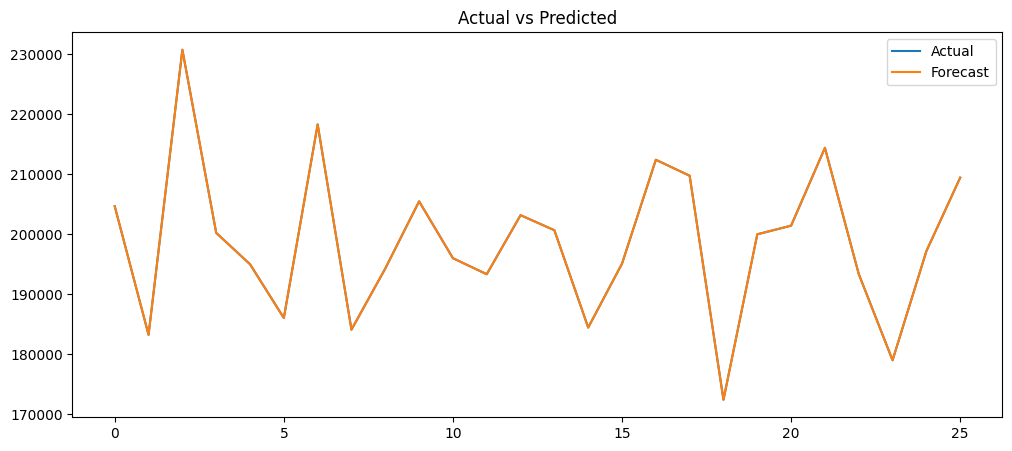

In [46]:
# Graphical Representation

plt.figure(figsize= (12 , 5))

plt.plot(y_test.values , label = "Actual")
plt.plot(y_pred , label = "Forecast")

plt.legend()

plt.title("Actual vs Predicted")

plt.show()